# Day 15 — Capstone: End-to-End Consumer Health Analytics

**Datasets:** Supermarket Sales + Medical Insurance

**Skills:** EDA · RFM · Cleaning · Risk Stratification · ML · Business Recommendation

**Goal:** Identify high-value customers at health risk — retention + wellness strategy

In [1]:
# Imports

import os, sys
os.chdir(os.path.expanduser('~/Desktop/DataAnalystJourney/day15-capstone'))
sys.path.append('src')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')
try:
    from cleaning import check_quality, remove_outliers_iqr
    print("✓ cleaning.py loaded")
except:
    print("⚠ cleaning.py not found")
sns.set_style("whitegrid")
print("✓ All libraries loaded")

✓ cleaning.py loaded
✓ All libraries loaded


In [2]:
#Load and clean

retail = pd.read_csv('data/supermarket_sales.csv')
health = pd.read_csv('data/insurance.csv')
print(f"Retail: {retail.shape} | Health: {health.shape}")
health_clean = health.copy()
health_clean = remove_outliers_iqr(health_clean, 'charges')
for col in ['sex','smoker','region']:
    health_clean[col] = health_clean[col].str.strip().str.lower()
health_clean['age_group'] = pd.cut(health_clean['age'],
    bins=[18,30,40,50,60,100],
    labels=['18-30','31-40','41-50','51-60','60+'])
health_clean['high_cost'] = (
    health_clean['charges'] > health_clean['charges'].median()).astype(int)
retail['Date'] = pd.to_datetime(retail['Date'])
print("✓ Cleaned")

Retail: (1000, 17) | Health: (1338, 7)
  Outliers removed from charges: 139 rows
✓ Cleaned


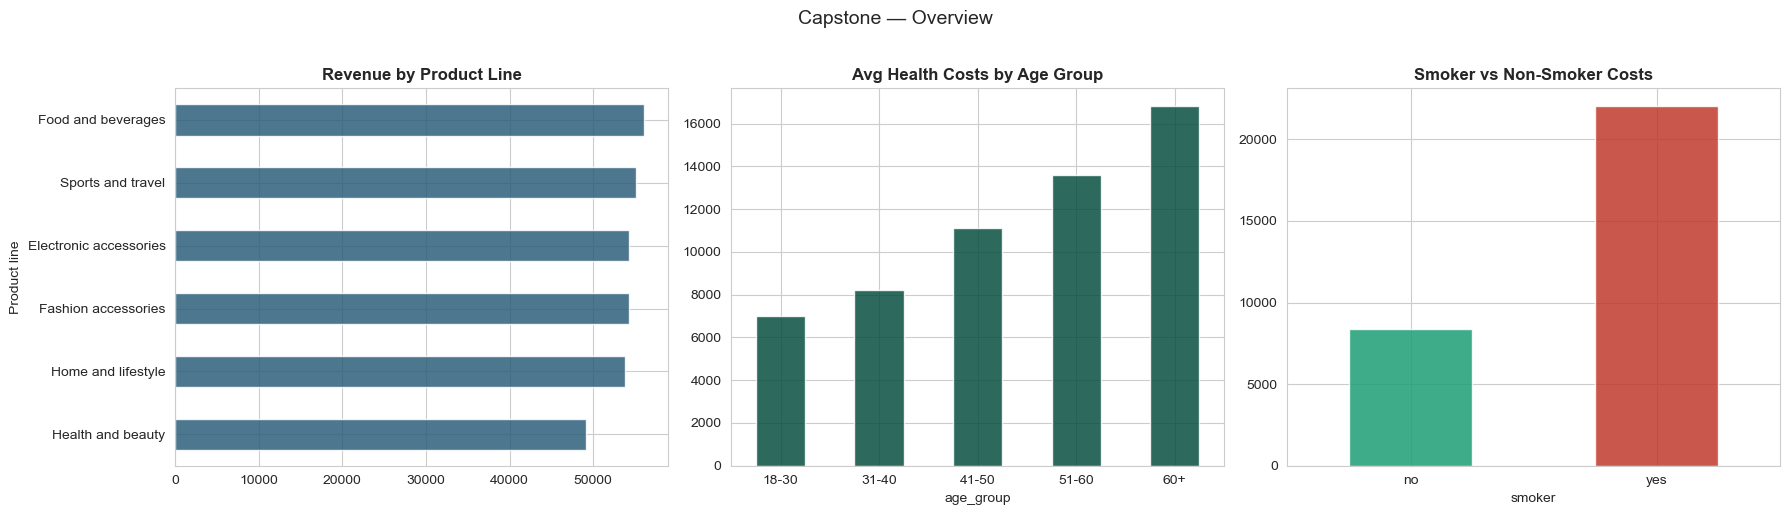

In [3]:
#EDA

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
retail.groupby('Product line')['Sales'].sum().sort_values().plot(
    kind='barh', ax=axes[0], color='#2C5F7A', alpha=0.85)
axes[0].set_title('Revenue by Product Line', fontweight='bold')
health_clean.groupby('age_group', observed=True)['charges'].mean().plot(
    kind='bar', ax=axes[1], color='#085041', alpha=0.85, edgecolor='white')
axes[1].set_title('Avg Health Costs by Age Group', fontweight='bold')
axes[1].tick_params(axis='x', rotation=0)
health_clean.groupby('smoker')['charges'].mean().plot(
    kind='bar', ax=axes[2], color=['#1D9E75','#C0392B'], alpha=0.85, edgecolor='white')
axes[2].set_title('Smoker vs Non-Smoker Costs', fontweight='bold')
axes[2].tick_params(axis='x', rotation=0)
plt.suptitle('Capstone — Overview', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('charts/capstone_eda.png', dpi=150, bbox_inches='tight')
plt.show()

In [4]:
#RFM Segmentation

snapshot = retail['Date'].max() + pd.DateOffset(days=1)
rfm = retail.groupby('Invoice ID').agg({
    'Date':       lambda x: (snapshot - x.max()).days,
    'Invoice ID': 'count',
    'Sales':      'sum'
}).rename(columns={'Date':'Recency','Invoice ID':'Frequency','Sales':'Monetary'})
rfm['R'] = pd.qcut(rfm['Recency'],  3, labels=[3,2,1])
rfm['F'] = pd.qcut(rfm['Frequency'].rank(method='first'), 3, labels=[1,2,3])
rfm['M'] = pd.qcut(rfm['Monetary'], 3, labels=[1,2,3])
def segment(row):
    score = int(row['R']) + int(row['F']) + int(row['M'])
    if score >= 8:   return 'Champions'
    elif score >= 6: return 'Loyal'
    elif score >= 4: return 'Potential'
    else:            return 'At Risk'
rfm['Segment'] = rfm.apply(segment, axis=1)
print(rfm['Segment'].value_counts())
print(rfm.groupby('Segment')['Monetary'].mean().round(2).sort_values(ascending=False))

Segment
Loyal        502
Potential    324
Champions    134
At Risk       40
Name: count, dtype: int64
Segment
Champions    542.83
Loyal        362.56
Potential    199.01
At Risk       93.59
Name: Monetary, dtype: float64


In [5]:
#Health risk model

le = LabelEncoder()
health_model = health_clean.copy()
for col in ['sex','smoker','region']:
    health_model[col] = le.fit_transform(health_model[col])
features = ['age','sex','bmi','children','smoker','region']
X = health_model[features]
y = health_model['high_cost']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)
y_prob = model.predict_proba(X_test)[:,1]
auc = roc_auc_score(y_test, y_prob)
print(f"✓ ROC-AUC: {auc:.4f}")
print(classification_report(y_test, model.predict(X_test),
      target_names=['Low Cost','High Cost']))

✓ ROC-AUC: 0.9631
              precision    recall  f1-score   support

    Low Cost       0.91      0.97      0.94       120
   High Cost       0.96      0.90      0.93       120

    accuracy                           0.93       240
   macro avg       0.94      0.93      0.93       240
weighted avg       0.94      0.93      0.93       240



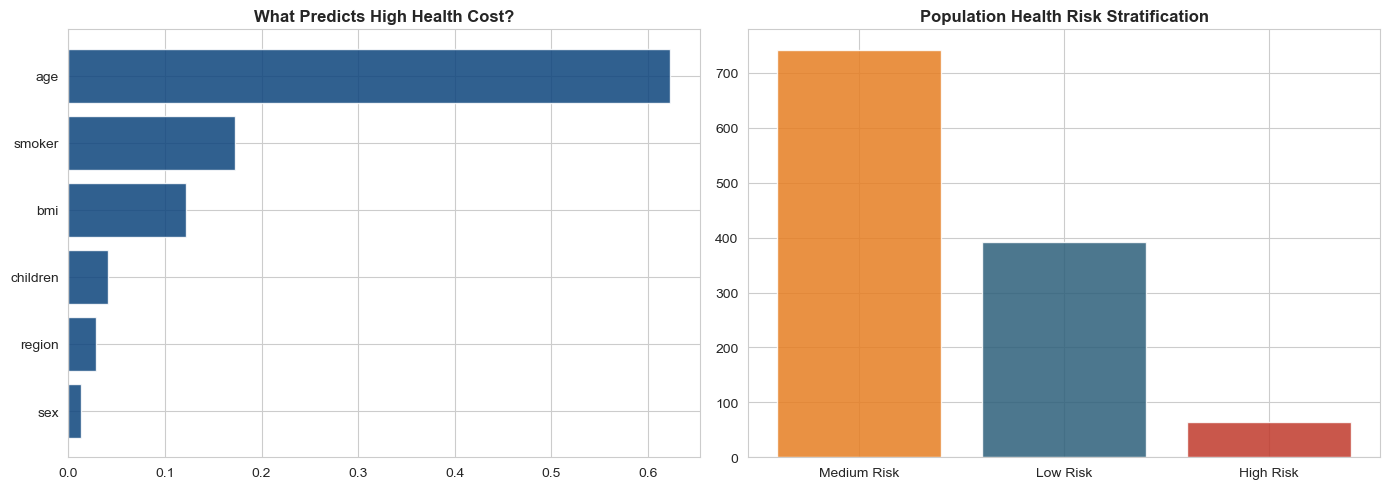

risk_tier
Medium Risk    742
Low Risk       392
High Risk       65
Name: count, dtype: int64


In [6]:
#Feature importance + risk tiers
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
feat_imp = pd.DataFrame({
    'Feature': features,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=True)
axes[0].barh(feat_imp['Feature'], feat_imp['Importance'],
             color='#0C447C', alpha=0.85, edgecolor='white')
axes[0].set_title('What Predicts High Health Cost?', fontweight='bold')
def health_risk_score(row):
    score = 0
    if row['smoker'] == 'yes': score += 3
    if row['bmi'] > 30:        score += 2
    if row['age'] > 50:        score += 2
    if row['children'] > 2:    score += 1
    return score
health_clean['risk_score'] = health_clean.apply(health_risk_score, axis=1)
health_clean['risk_tier'] = pd.cut(health_clean['risk_score'],
    bins=[-1,1,4,10], labels=['Low Risk','Medium Risk','High Risk'])
tier_counts = health_clean['risk_tier'].value_counts()
colors = {'High Risk':'#C0392B','Medium Risk':'#E67E22','Low Risk':'#2C5F7A'}
axes[1].bar(tier_counts.index, tier_counts.values,
            color=[colors[t] for t in tier_counts.index],
            edgecolor='white', alpha=0.85)
axes[1].set_title('Population Health Risk Stratification', fontweight='bold')
plt.tight_layout()
plt.savefig('charts/capstone_ml.png', dpi=150, bbox_inches='tight')
plt.show()
print(tier_counts)

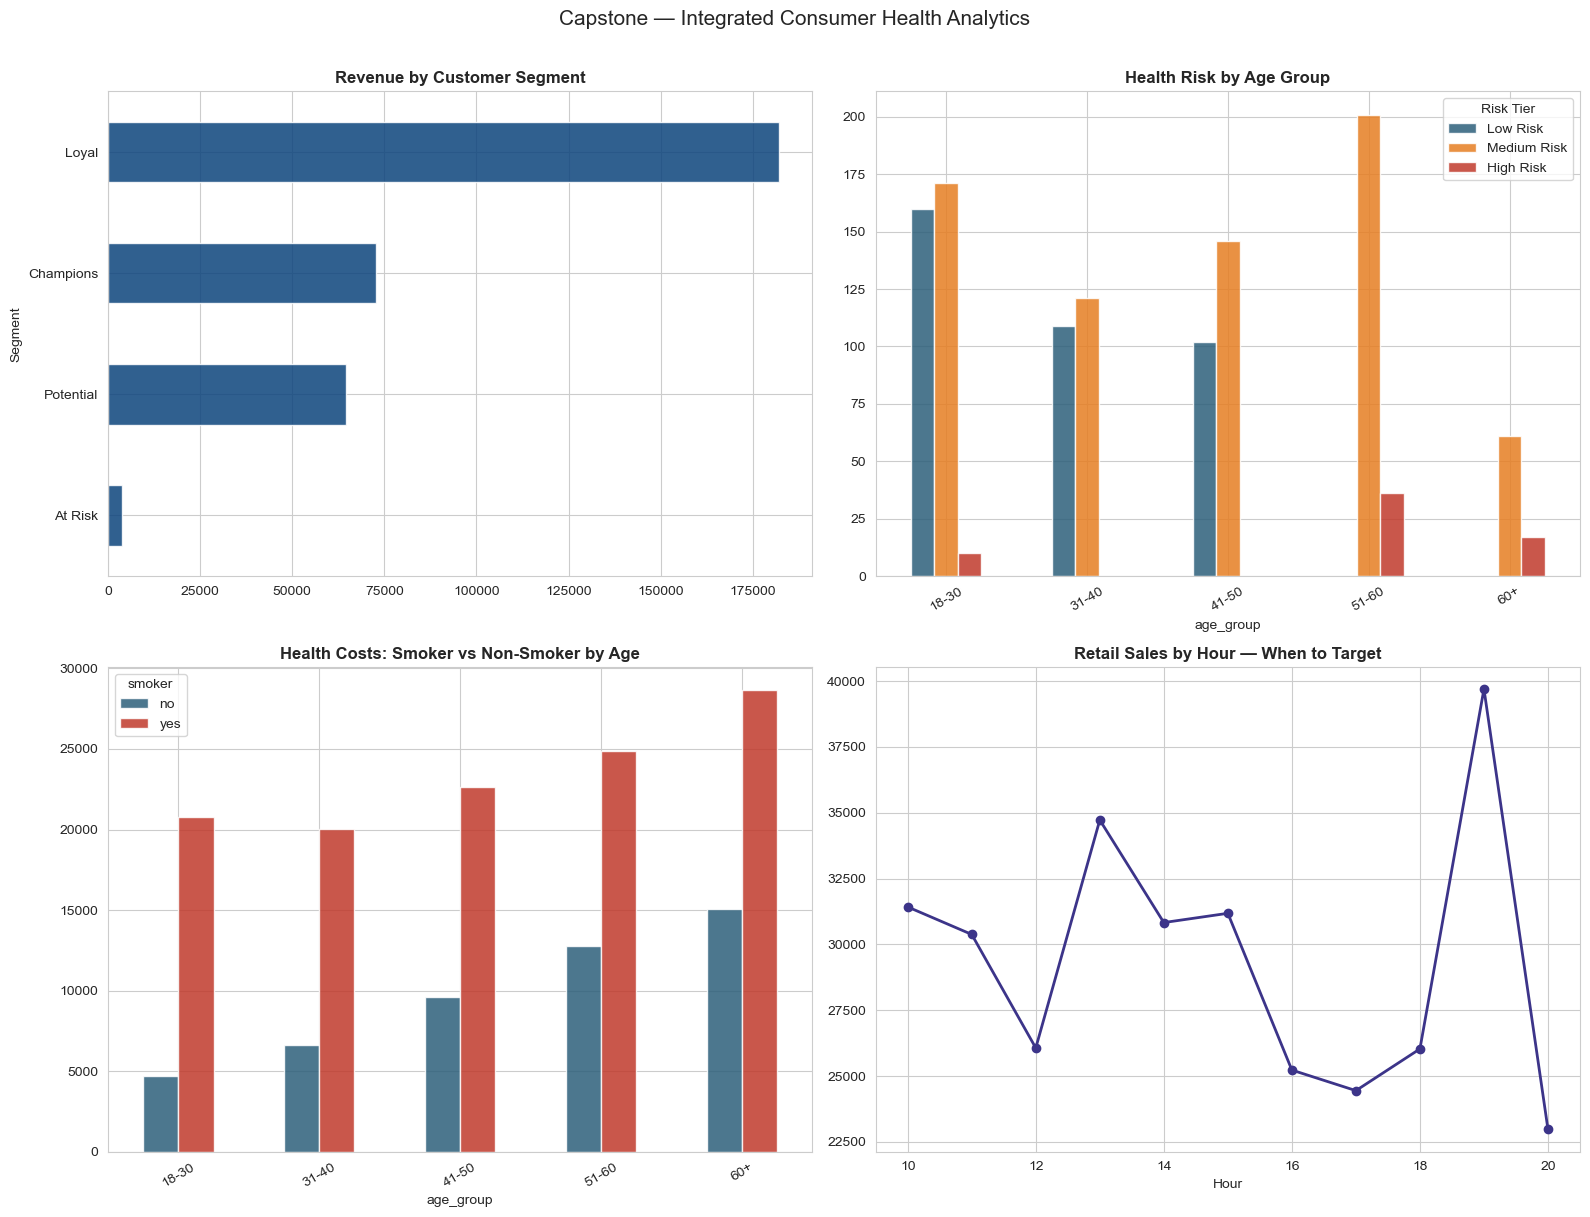

In [7]:
# Integrated 4-panel chart

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
rfm.groupby('Segment')['Monetary'].sum().sort_values().plot(
    kind='barh', ax=axes[0,0], color='#0C447C', alpha=0.85)
axes[0,0].set_title('Revenue by Customer Segment', fontweight='bold')
health_clean.groupby(['age_group','risk_tier'], observed=True).size().unstack(
    fill_value=0).plot(kind='bar', ax=axes[0,1],
    color=['#2C5F7A','#E67E22','#C0392B'], edgecolor='white', alpha=0.85)
axes[0,1].set_title('Health Risk by Age Group', fontweight='bold')
axes[0,1].tick_params(axis='x', rotation=30)
axes[0,1].legend(title='Risk Tier')
health_clean.groupby(['age_group','smoker'], observed=True)['charges'].mean().unstack().plot(
    kind='bar', ax=axes[1,0],
    color=['#2C5F7A','#C0392B'], edgecolor='white', alpha=0.85)
axes[1,0].set_title('Health Costs: Smoker vs Non-Smoker by Age', fontweight='bold')
axes[1,0].tick_params(axis='x', rotation=30)
retail['Hour'] = pd.to_datetime(retail['Time']).dt.hour
retail.groupby('Hour')['Sales'].sum().plot(
    kind='line', ax=axes[1,1], marker='o', color='#3C3489', linewidth=2)
axes[1,1].set_title('Retail Sales by Hour — When to Target', fontweight='bold')
plt.suptitle('Capstone — Integrated Consumer Health Analytics', fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig('charts/capstone_integrated.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# Board recommendation

avg_spend       = retail['Sales'].mean()
champions_spend = rfm[rfm['Segment']=='Champions']['Monetary'].mean()
high_risk_count = (health_clean['risk_tier']=='High Risk').sum()
avg_charges     = health_clean['charges'].mean()
smoker_premium  = (health_clean[health_clean['smoker']=='yes']['charges'].mean() -
                   health_clean[health_clean['smoker']=='no']['charges'].mean())
print("=" * 55)
print("  BOARD RECOMMENDATION — CONSUMER HEALTH GROUP")
print("=" * 55)
print(f"\nCUSTOMER VALUE")
print(f"  Avg transaction value:          £{avg_spend:.2f}")
print(f"  Champions avg lifetime spend:   £{champions_spend:.2f}")
print(f"\nHEALTH RISK PROFILE")
print(f"  High Risk population:           {high_risk_count} ({high_risk_count/len(health_clean)*100:.1f}%)")
print(f"  Avg annual insurance charges:   £{avg_charges:,.0f}")
print(f"  Smoker cost premium:            £{smoker_premium:,.0f}/year")
print(f"\nSTRATEGIC RECOMMENDATION")
print(f"  1. Wellness programme targeting High Risk 40-60 segment")
print(f"  2. Smoking cessation — £{smoker_premium:,.0f} saving per quitter annually")
print(f"  3. Protect Champions with loyalty pricing at peak hours (7pm)")
print(f"  4. At Risk customers — win-back campaign before they churn")
print(f"\n  PRIORITY: High Risk + Champions intersection")
print(f"  Dual ROI — highest spend AND highest health cost burden")

  BOARD RECOMMENDATION — CONSUMER HEALTH GROUP

CUSTOMER VALUE
  Avg transaction value:          £322.97
  Champions avg lifetime spend:   £542.83

HEALTH RISK PROFILE
  High Risk population:           65 (5.4%)
  Avg annual insurance charges:   £9,928
  Smoker cost premium:            £13,659/year

STRATEGIC RECOMMENDATION
  1. Wellness programme targeting High Risk 40-60 segment
  2. Smoking cessation — £13,659 saving per quitter annually
  3. Protect Champions with loyalty pricing at peak hours (7pm)
  4. At Risk customers — win-back campaign before they churn

  PRIORITY: High Risk + Champions intersection
  Dual ROI — highest spend AND highest health cost burden


## Capstone Executive Summary — Consumer Health Analytics

### Customer Segmentation (RFM)
- 1,000 transactions analysed across 3 branches
- Champions (134 customers): avg lifetime spend £542.83 — top retention priority
- Loyal (502 customers): largest segment, avg spend £362.56
- At Risk (40 customers): immediate win-back campaign needed
- Champions spend 5.8x more than At Risk customers

### Health Risk Profile
- 1,199 patients analysed after outlier removal
- High Risk: 65 patients (5.4%) — primary wellness intervention target
- Medium Risk: 742 patients (61.9%) — prevention focus
- Low Risk: 392 patients (32.7%) — maintenance programmes
- Smokers incur £13,659 more per year than non-smokers
- Average annual insurance charges: £9,928

### ML Model Performance
- Algorithm: Random Forest health risk classifier
- ROC-AUC: 0.96 — excellent discrimination
- Overall accuracy: 93%
- High Cost precision: 96% · recall: 90%
- Top predictors: Age, BMI, Smoking status

### Integrated Recommendation
Target the 40-60 Champions who are also High Risk for a premium
wellness programme. Dual financial benefit:
- Protect retail revenue (Champions avg £542.83 spend)
- Reduce insurance costs (£13,659 smoker premium per person)

### Financial Case
- Avg transaction value: £322.97
- Champions avg lifetime spend: £542.83
- Smoking cessation saving: £13,659 per quitter annually
- 50 successful quitters = £682,950 saved in year one alone
- Wellness targeting High Risk 65 patients: reduces future insurance claims